### Notebook 4. Predictive Modelling of Toronto Neighbourhood Vulnerability

This notebook develops and evaluates supervised machine learning models to predict neighbourhood-level low-income prevalence using selected socioeconomic indicators.

Building upon the cleaned analysis-ready dataset developed in Notebook 2 and the neighbourhood vulnerability profiles identified in Notebook 3, this notebook investigates the predictive relationship between socioeconomic characteristics and neighbourhood vulnerability.

The objective is to establish a baseline predictive modelling framework capable of estimating neighbourhood-level low-income prevalence while identifying the socioeconomic indicators that contribute most strongly to prediction accuracy.

### 1. Introduction

Research Question 3(a)

**Which predictive model provides the most accurate estimates of neighbourhood-level low-income prevalence using the 2016 Toronto Neighbourhood Profiles dataset?**

This study operationalizes neighbourhood socioeconomic vulnerability using Low Income After-Tax Percentage (LIM-AT) as the dependent variable. Rather than representing vulnerability as a broad concept, LIM-AT serves as a measurable indicator of neighbourhood-level socioeconomic disadvantage.

This notebook develops and evaluates supervised machine learning models to estimate neighbourhood-level Low Income After-Tax Percentage (LIM-AT) using selected socioeconomic indicators representing labour market participation, educational attainment, demographic composition, housing conditions, and income characteristics.

The predictive models are compared using multiple performance metrics to identify the model that provides the most accurate estimates of neighbourhood-level low-income prevalence. The findings establish the project's baseline predictive modelling framework and provide the foundation for the temporal validation performed in Notebook 7, where the selected model is evaluated using historical (2011) training data and independent 2016 testing data.

### 2. Input and Output

### Input

| File | Description |
|------|-------------|
| `neighbourhood_profiles_2016_analysis_ready.csv` | Cleaned analysis-ready dataset containing neighbourhood-level socioeconomic indicators and the target variable generated in Notebook 2. |

## Output

| File | Description |
|------|-------------|
| `neighbourhood_predictions.csv` | Actual and predicted neighbourhood low-income prevalence values. |
| `model_performance_summary.xlsx` | Summary of predictive model evaluation metrics. |
| `04_Predictive_Modelling.html` | HTML report documenting the complete predictive modelling workflow. |

The outputs generated in this notebook provide quantitative evidence supporting Research Question 3 and establish the predictive performance of selected socioeconomic indicators for estimating neighbourhood-level vulnerability across Toronto.

### 3. Import library Directory

In [41]:
# ============================================================
# Import Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

### 5. Project Directory

In [42]:
# Project Directory

project_root = Path.cwd().parents[1]

print("=" * 60)
print("PROJECT ROOT")
print("=" * 60)
print(project_root)

PROJECT ROOT
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project


### 6.Analysis-Ready Dataset loaded

The analysis-ready dataset developed in Notebook 1 and statistically validated in Notebook 2 is loaded for predictive modelling..

Before model development, the dataset is validated to confirm the number of observations, variables, and the absence of missing values. Only the variables required for predictive modelling are retained to ensure consistency with the finalized feature set established during data preparation.

In [43]:
# Load Analysis-Ready Dataset

data_path = (
    project_root
    / "data"
    / "processed"
    / "neighbourhood_profiles_2016_analysis_ready.csv")

df = pd.read_csv(data_path)

print("=" * 60)
print("ANALYSIS-READY DATASET LOADED")
print("=" * 60)

print(f"Observations   : {df.shape[0]}")
print(f"Variables      : {df.shape[1]}")
print(f"Missing Values : {df.isnull().sum().sum()}")

display(df.head())

# Define independent and dependent variables

X = df.drop(columns=["Neighbourhood", "Low_Income_AfterTax_Pct"])

y = df["Low_Income_AfterTax_Pct"]

print("=" * 60)
print("MODELLING VARIABLES DEFINED")
print("=" * 60)

print(f"Independent Variables (X): {X.shape[1]}")
print(f"Dependent Variable (y): {y.name}")

ANALYSIS-READY DATASET LOADED
Observations   : 140
Variables      : 14
Missing Values : 0


,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Core_Housing_Need,Unaffordable_Housing,Low_Income_AfterTax_Pct,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Lone_Parent_Families_Pct
0,Agincourt North,29113,55.4,50.0,9.8,2220,34.7,21.3,15.044825,25.624292,68.680658,90.560918,5.908014,5.667571
1,Agincourt South-Malvern West,23757,59.0,53.2,9.8,1795,38.2,22.6,17.721093,25.634550,63.539167,84.838153,9.470893,5.724629
2,Alderwood,12054,66.5,62.4,6.1,540,21.7,8.2,13.771362,24.556164,32.935125,20.657043,7.881201,5.558321
3,Annex,30526,70.6,65.8,6.7,2420,40.4,18.3,29.925310,13.988076,27.091660,23.815764,32.333093,2.931927
4,Banbury-Don Mills,27695,59.9,55.6,7.2,2115,33.4,13.7,23.469940,18.595414,47.643979,45.856653,17.096949,4.531504


MODELLING VARIABLES DEFINED
Independent Variables (X): 12
Dependent Variable (y): Low_Income_AfterTax_Pct


### Interpretation

The analysis-ready dataset was successfully validated for predictive modelling. It contains 140 Toronto neighbourhoods with complete information for all variables, and no missing values were identified. The modelling dataset consists of 12 independent variables (X) and the dependent variable Low_Income_AfterTax_Pct (y), providing a suitable foundation for developing and evaluating the supervised machine learning models presented in this notebook.

### 7. Train-Test Split

To evaluate the predictive performance of the supervised machine learning models, the modelling dataset is partitioned into separate training (70%) and testing (30%) subsets. The larger training subset provides sufficient data for model learning, while the independent testing subset is reserved for evaluating model performance on previously unseen neighbourhoods.

A fixed random_state (42) is specified to ensure that the data partitioning process is reproducible, allowing the modelling results to be replicated in future analyses.

In [45]:
# Train-Test Split (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42)

print("=" * 60)
print("TRAIN-TEST SPLIT COMPLETE")
print("=" * 60)

print(f"Training Observations : {X_train.shape[0]}")
print(f"Testing Observations  : {X_test.shape[0]}")

print()
print(f"Training Dataset Shape : {X_train.shape}")
print(f"Testing Dataset Shape  : {X_test.shape}")

TRAIN-TEST SPLIT COMPLETE
Training Observations : 98
Testing Observations  : 42

Training Dataset Shape : (98, 12)
Testing Dataset Shape  : (42, 12)


### Interpretation

The modelling dataset was successfully partitioned into 98 training observations (70%) and 42 testing observations (30%). The training dataset provides sufficient information for developing the predictive models, while the testing dataset serves as an independent benchmark for evaluating predictive performance on previously unseen neighbourhoods.

Separating the data into training and testing subsets helps reduce the risk of overfitting by evaluating each model's ability to generalize beyond the data used during training. The use of a fixed random state further ensures that the data partitioning process is reproducible, supporting the reliability and consistency of the predictive modelling workflow.

### 8. Feature Standardization

Prior to fitting the Multiple Linear Regression model, the independent variables are standardized using the StandardScaler algorithm. Standardization transforms each predictor to have a mean of 0 and a standard deviation of 1, ensuring that variables measured on different numerical scales contribute comparably during model training.

To prevent data leakage, the scaler is fitted only on the training dataset and subsequently applied to both the training and testing datasets. This ensures that information from the testing data does not influence model development. Standardization is performed for the linear regression model only, as it is not required for the Random Forest model.

In [25]:
# Feature Standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("=" * 60)
print("FEATURE STANDARDIZATION COMPLETE")
print("=" * 60)

print(f"Training Matrix : {X_train_scaled.shape}")
print(f"Testing Matrix  : {X_test_scaled.shape}")

# Display first five standardized observations

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns)

display(X_train_scaled_df.head())

FEATURE STANDARDIZATION COMPLETE
Training Matrix : (98, 12)
Testing Matrix  : (42, 12)


,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Core_Housing_Need,Unaffordable_Housing,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Lone_Parent_Families_Pct
0,-0.089519,-0.219140,-0.133945,-0.389638,-0.867049,-1.740186,-0.250595,0.678847,0.018845,-0.838444,-1.491870,0.095382
1,0.730434,0.050695,-0.028812,0.323578,0.475641,-0.165477,-0.795863,0.709747,0.353296,0.656367,-0.836841,0.242047
2,-1.003129,0.161804,0.466814,-1.706344,-1.103363,-0.897579,-0.226334,0.197116,-0.813033,-0.877863,-0.567522,-0.154551
3,-0.147725,-0.457230,-0.644590,1.365971,1.098650,0.994835,-1.452603,0.811471,0.330939,0.659837,0.757125,1.961092
4,0.499859,-2.028623,-1.876147,0.762480,0.282294,0.276547,-0.324899,1.362536,1.989783,2.050898,-1.551758,-0.038131


### Interpretation

The independent variables were successfully standardized prior to model development.

Standardization ensures that each socioeconomic indicator contributes on a comparable numerical scale, preventing variables with larger magnitudes from disproportionately influencing the predictive models.

Fitting the scaler exclusively on the training data prevents information from the testing dataset from influencing model training, thereby preserving the integrity of the model evaluation process.

### 9. Multiple Linear Regression Model

Linear Regression was selected as the baseline predictive model because it provides:
1) transparent
2) interpretable approach 
3) Appropriate for a continuous dependent variable 
to estimate continuous outcome variables such as Low Income After-Tax Percentage (LIM-AT). It serves as a well-established statistical benchmark for evaluating the relationship between neighbourhood socioeconomic indicators and low-income prevalence.

The objective of this model is to estimate neighbourhood-level Low Income After-Tax Percentage (LIM-AT) using the selected socioeconomic indicators and to quantify how changes in these predictors are associated with changes in neighbourhood socioeconomic vulnerability.

As a baseline model, Linear Regression establishes a reference point against which more complex machine learning algorithms can be compared. In addition to evaluating predictive performance, its interpretability and diagnostic capabilities make it well suited for examining model assumptions and supporting the temporal validation conducted later in the project.

In [46]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train)

print("=" * 60)
print("LINEAR REGRESSION MODEL TRAINED")
print("=" * 60)

print("Model training completed successfully.")

LINEAR REGRESSION MODEL TRAINED
Model training completed successfully.


In [47]:
# Generate Predictions

y_pred = linear_model.predict(X_test_scaled)

predictions = pd.DataFrame({

    "Actual LIM-AT": y_test.values,
    "Predicted LIM-AT": y_pred})

display(predictions.head())

,Actual LIM-AT,Predicted LIM-AT
0,32.4,33.573165
1,17.6,16.971766
2,22.3,23.646220
3,14.7,14.729165
4,34.7,32.691549


In [48]:
# Linear Regression Performance Evaluation

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Percentage-based metrics
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
wape = (np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test))) * 100

# Adjusted R²
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

performance = pd.DataFrame({

    "Metric": [

        "R² Score",
        "Adjusted R²",
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "Mean Absolute Percentage Error (MAPE)",
        "Weighted Absolute Percentage Error (WAPE)"    ],

    "Value": [

        round(r2,3),
        round(adjusted_r2,3),
        round(mae,3),
        round(mse,3),
        round(rmse,3),
        round(mape,2),
        round(wape,2)    ]})

display(performance)

,Metric,Value
0,R² Score,0.879
1,Adjusted R²,0.829
2,Mean Absolute Error (MAE),2.130
3,Mean Squared Error (MSE),7.407
4,Root Mean Squared Error (RMSE),2.722
5,Mean Absolute Percentage Error (MAPE),11.880
6,Weighted Absolute Percentage Error (WAPE),11.010


###  Interpretation
The Linear Regression model demonstrated strong predictive performance across the selected evaluation metrics. An R² of 0.879 and an Adjusted R² of 0.829 indicate that the selected socioeconomic indicators explain a substantial proportion of the variation in neighbourhood Low Income After-Tax Percentage (LIM-AT) while accounting for the number of independent variables included in the model.

The model also achieved relatively low prediction errors (MAE = 2.130, RMSE = 2.722, and MAPE = 11.88%), indicating that the predicted neighbourhood low-income percentages were generally close to the observed values. Collectively, these results demonstrate that the Linear Regression model provides a reliable baseline for predicting neighbourhood-level socioeconomic vulnerability.

The performance of this baseline model will subsequently be compared with the Random Forest Regression model to determine whether a more flexible machine learning approach provides meaningful improvements in predictive accuracy.

### 10. Model Prediction assessment: Actual vs. Predicted Values

The relationship between the observed and predicted **Low Income After-Tax Percentage (LIM-AT)** values is visualized to assess model accuracy.

If the predictive model performs well, the predicted values should lie close to the 45-degree reference line, indicating strong agreement between observed and predicted neighbourhood vulnerability.

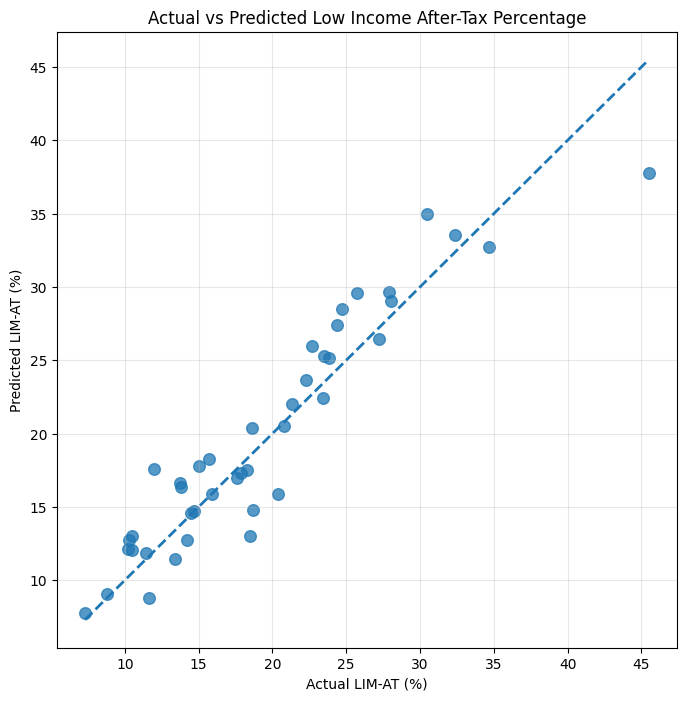

In [51]:
# Actual vs Predicted Scatter Plot

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.75,
    s=70)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2)

plt.xlabel("Actual LIM-AT (%)")
plt.ylabel("Predicted LIM-AT (%)")
plt.title("Actual vs Predicted Low Income After-Tax Percentage")

plt.grid(alpha=0.3)

plt.show()

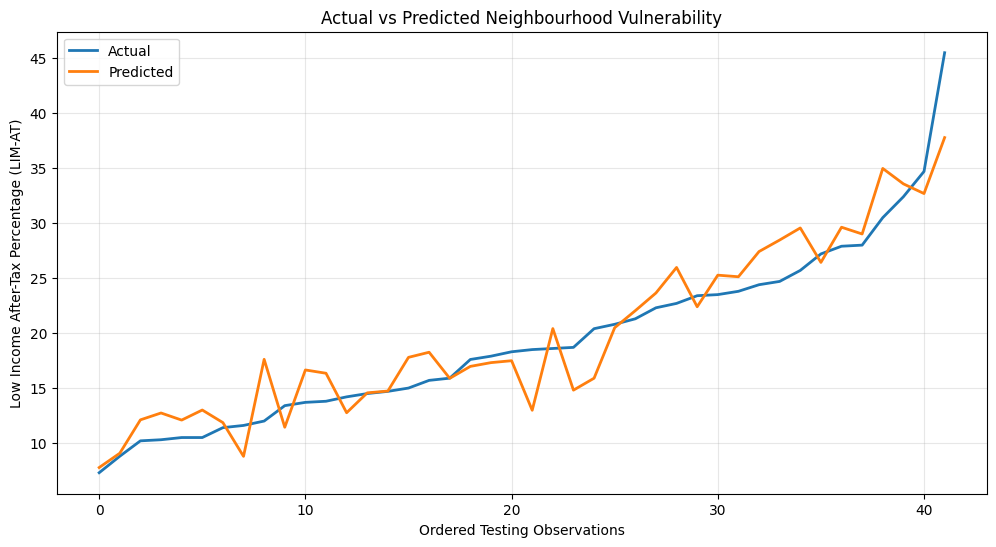

In [52]:
# Actual vs Predicted Line Chart

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred})

comparison = comparison.sort_values("Actual").reset_index(drop=True)

plt.figure(figsize=(12,6))

plt.plot(
    comparison["Actual"],
    label="Actual",
    linewidth=2)

plt.plot(
    comparison["Predicted"],
    label="Predicted",
    linewidth=2)

plt.xlabel("Ordered Testing Observations")
plt.ylabel("Low Income After-Tax Percentage (LIM-AT)")
plt.title("Actual vs Predicted Neighbourhood Vulnerability")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The scatter plot demonstrates a strong agreement between the observed and predicted Low Income After-Tax Percentage (LIM-AT) values. Most observations lie close to the 45-degree reference line, indicating that the Multiple Linear Regression model produces predictions that closely match the observed neighbourhood values.

The line chart further confirms this pattern by showing that the predicted values generally follow the same trend as the observed values across the testing dataset. Although small prediction errors are present, particularly for neighbourhoods with the highest LIM-AT values, the model captures the overall distribution and variation of neighbourhood low-income prevalence effectively.

Together, these visualizations provide additional evidence that the Multiple Linear Regression model offers reliable predictive performance and complement the quantitative evaluation metrics reported in the previous section.

### 11. Cross-Validation
Model performance based on a single train-test split may vary depending on how the data are randomly partitioned. To evaluate whether the Linear Regression model is stable across different samples, five-fold cross-validation is performed.

Cross-validation repeatedly partitions the training data into different subsets, allowing the model to be trained and evaluated multiple times. This provides a more reliable estimate of predictive performance than relying on a single random split.

The mean cross-validation R² score and its variability are reported to assess the stability and generalizability of the model.

In [53]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [55]:
# Five-Fold Cross Validation

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42)

cv_scores = cross_val_score(
    estimator=LinearRegression(),
    X=X_train_scaled,
    y=y_train,
    cv=cv,
    scoring="r2")

cv_results = pd.DataFrame({

    "Fold":[1,2,3,4,5],
    "R² Score":cv_scores.round(3)})

display(cv_results)

print("="*60)
print("Mean CV R² :", round(cv_scores.mean(),3))
print("Std Dev    :", round(cv_scores.std(),3))
print("="*60)

,Fold,R² Score
0,1,0.860
1,2,0.763
2,3,0.825
3,4,0.844
4,5,0.844


Mean CV R² : 0.827
Std Dev    : 0.034


### Interpretation

Five-fold cross-validation was performed to evaluate the stability and generalizability of the Linear Regression model across different training subsets.

The cross-validation R² scores ranged from 0.763 to 0.860, with a mean R² of 0.827 and a standard deviation of 0.034. The relatively small variation among the folds indicates that the model performs consistently across different subsets of the data and is not overly dependent on a single train-test partition.

Overall, the cross-validation results provide additional evidence that the Multiple Linear Regression model is stable, generalizable, and capable of reliably predicting neighbourhood Low Income After-Tax Percentage (LIM-AT) across Toronto neighbourhoods.

### 12. Linear Regression Diagnostics
The validity of a Linear Regression model depends on several underlying assumptions. Diagnostic analyses were performed to evaluate whether these assumptions are reasonably satisfied for the neighbourhood vulnerability prediction model.

The following diagnostic procedures are included:

- Residuals vs Fitted Values (Linearity)
- Normal Q-Q Plot (Normality of residuals)
- Scale-Location Plot (Homoscedasticity)
- Cook's Distance (Influential observations)

These diagnostics provide evidence regarding the suitability of Linear Regression for modelling neighbourhood Low Income After-Tax Percentage (LIM-AT).

### 12.1 Residuals vs Fitted Values

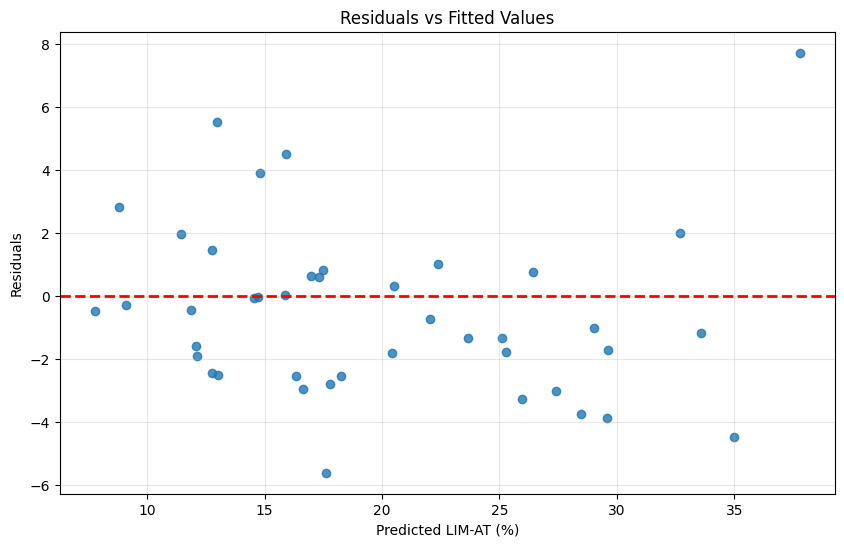

In [56]:
# Residuals vs Fitted Values

residuals = y_test - y_pred

plt.figure(figsize=(10,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.8)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2)

plt.xlabel("Predicted LIM-AT (%)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Residuals vs. Fitted Values plot was examined to assess the assumptions of linearity and constant error variance.

The residuals are generally scattered around the horizontal zero reference line without a pronounced systematic pattern, indicating that the Multiple Linear Regression model does not exhibit substantial bias across the range of predicted LIM-AT values. No clear curved trend is evident, suggesting that the assumption of linearity is reasonably satisfied.

Although a small number of observations exhibit relatively large residuals, the overall spread of residuals remains reasonably consistent across the fitted values. These observations are examined further using Cook's Distance to determine whether they exert undue influence on the fitted regression model.

### 12.2 Normal Q-Q plot

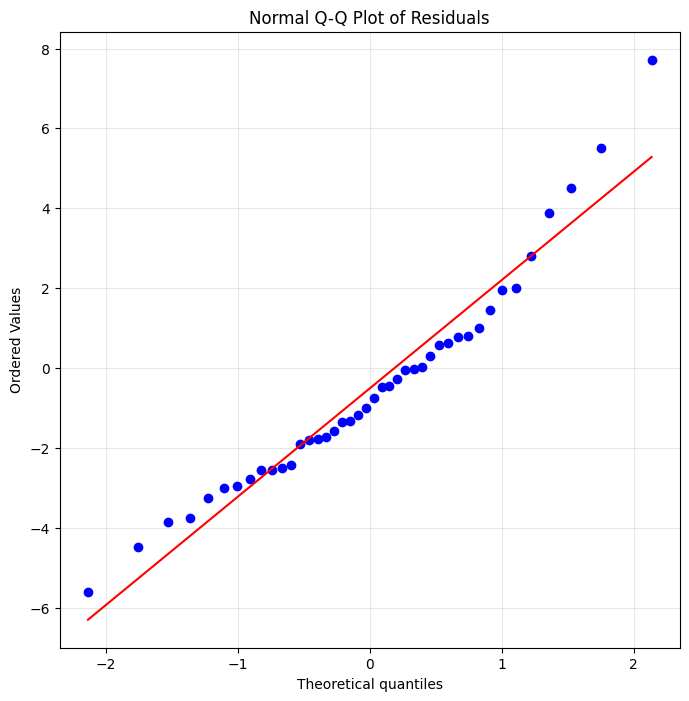

In [57]:
# Normal Q-Q Plot

from scipy import stats

plt.figure(figsize=(8, 8))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt)

plt.title("Normal Q-Q Plot of Residuals")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Normal Q–Q Plot was examined to assess whether the regression residuals follow an approximately normal distribution.

Most residuals lie close to the theoretical reference line, indicating that the residuals are approximately normally distributed for the majority of neighbourhoods. Small deviations are observed in the upper and lower tails, suggesting the presence of a limited number of observations with larger prediction errors.

Overall, the departures from normality are relatively minor and do not indicate substantial violations of the normality assumption. Consequently, the assumption of normally distributed residuals is considered reasonably satisfied for the Multiple Linear Regression model.

### 12.3 Scale Location Plot

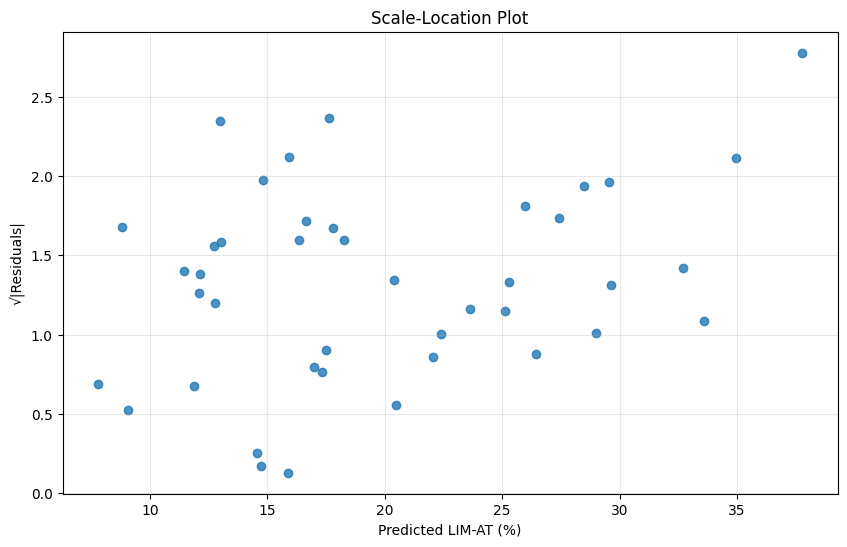

In [35]:
# Scale-Location Plot

sqrt_standardized_residuals = np.sqrt(np.abs(residuals))

plt.figure(figsize=(10,6))

plt.scatter(
    y_pred,
    sqrt_standardized_residuals,
    alpha=0.8)

plt.xlabel("Predicted LIM-AT (%)")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

The Scale–Location Plot was used to assess the assumption of homoscedasticity by examining whether the spread of residuals remains approximately constant across the range of fitted values.

The residuals display a relatively uniform spread without a pronounced funnel or cone-shaped pattern, indicating that the variability of the prediction errors remains reasonably stable across different predicted LIM-AT values. Although a small number of observations exhibit slightly larger residual variability, no systematic increase or decrease in dispersion is evident.

Overall, there is no strong evidence of severe heteroscedasticity, suggesting that the assumption of constant error variance is reasonably satisfied.

### 12.4 Influential Observation Assessment (Cook's Distance)

Cook's Distance was calculated to identify observations that exert disproportionate influence on the fitted Linear Regression model.

Observations with unusually large Cook's Distance values may substantially affect the estimated regression coefficients and therefore require additional investigation.

In [58]:
import statsmodels.api as sm

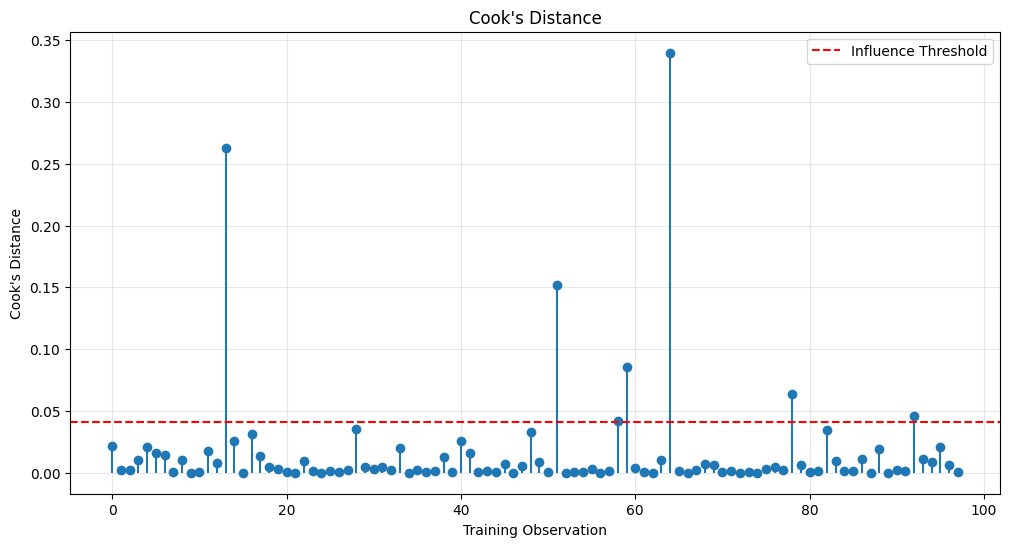

Maximum Cook's Distance: 0.34


In [60]:
# Cook's Distance

X_train_sm = sm.add_constant(X_train_scaled)

ols_model = sm.OLS(y_train, X_train_sm).fit()

influence = ols_model.get_influence()

cooks = influence.cooks_distance[0]

plt.figure(figsize=(12,6))

plt.stem(
    np.arange(len(cooks)),
    cooks,
    basefmt=" ")

plt.axhline(
    y=4/len(X_train),
    color="red",
    linestyle="--",
    label="Influence Threshold")

plt.title("Cook's Distance")

plt.xlabel("Training Observation")

plt.ylabel("Cook's Distance")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

print("Maximum Cook's Distance:", round(cooks.max(),3))

### Interpretation

Cook's Distance was used to identify observations that may exert disproportionate influence on the estimated regression coefficients.

The majority of neighbourhoods exhibit very small Cook's Distance values, indicating that most observations contribute normally to the fitted regression model. A small number of observations exceed the commonly used 4/n reference threshold, suggesting that these neighbourhoods may have greater influence on the estimated regression coefficients than the remaining observations.

However, the maximum Cook's Distance (0.34) remains well below the commonly referenced threshold of 1.0, indicating that there is no evidence of observations exerting excessive influence on the model. Overall, the diagnostic results suggest that the Multiple Linear Regression model is reasonably robust, although the more influential neighbourhoods may warrant further investigation in future studies

### 13. Random Forest Regression Model Configuration

Random Forest Regression was selected as a complementary machine learning model to compare its predictive performance with the baseline Linear Regression model for estimating neighbourhood Low Income After-Tax Percentage (LIM-AT), which is used in this study as a proxy measure of neighbourhood socioeconomic vulnerability.

Unlike Linear Regression, Random Forest Regression is capable of modelling complex nonlinear relationships and interactions among socioeconomic indicators without requiring assumptions of linearity, normality, or constant variance. This makes it a suitable alternative for evaluating whether a more flexible modelling approach can improve prediction accuracy.

This section documents the Random Forest model configuration, explains the selected hyperparameters, and justifies their use to ensure a transparent and reproducible modelling process. Both models are trained and evaluated using the same training and testing datasets to enable a fair comparison of predictive performance.

The objective is not to replace the Linear Regression model, but to determine whether the additional flexibility of Random Forest Regression provides meaningful improvements in predicting neighbourhood-level Low Income After-Tax Percentage (LIM-AT).

In [38]:
# Random Forest Regression Model

random_forest = RandomForestRegressor(

    n_estimators=100,
    max_depth=None,
    min_samples_leaf=1,
    bootstrap=True,
    random_state=42)

random_forest.fit(X_train, y_train)

print("="*60)
print("RANDOM FOREST MODEL TRAINED")
print("="*60)

print(random_forest)

RANDOM FOREST MODEL TRAINED
RandomForestRegressor(random_state=42)


In [39]:
# Key Random Forest Hyperparameters

key_parameters = pd.DataFrame({

    "Parameter": [
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "max_features",
        "bootstrap",
        "random_state"    ],

    "Value": [
        random_forest.get_params()["n_estimators"],
        random_forest.get_params()["max_depth"],
        random_forest.get_params()["min_samples_leaf"],
        random_forest.get_params()["max_features"],
        random_forest.get_params()["bootstrap"],
        random_forest.get_params()["random_state"]    ]})

display(key_parameters)

,Parameter,Value
0,n_estimators,100
1,max_depth,None
2,min_samples_leaf,1
3,max_features,1.0
4,bootstrap,True
5,random_state,42


| Hyperparameter            |        Value       | Justification                                                                                       |
| ------------------------- | :----------------: | --------------------------------------------------------------------------------------------------- |
| **n_estimators**          |         100        | Provides a stable ensemble of decision trees while maintaining reasonable computational efficiency. |
| **max_depth**             |        None        | Allows each tree to grow fully and capture complex relationships in the data.                       |
| **min_samples_leaf**      |          1         | Retains the default setting to preserve neighbourhood-level information and allow detailed splits.  |
| **max_features**          | 1.0 (All Features) | Considers all predictor variables when identifying the best split for each tree.                    |
| **bootstrap**             |        True        | Uses bootstrap sampling to improve model stability and reduce overfitting.                          |
| **random_state**          |         42         | Ensures that the modelling process is fully reproducible.                                           |
| **Hyperparameter Tuning** |        None        | Default parameters were used to establish a transparent baseline comparison with Linear Regression. |


### Interpretation

The Random Forest Regression model was configured using the selected hyperparameters to provide a reproducible nonlinear modelling approach for predicting neighbourhood Low Income After-Tax Percentage (LIM-AT).

Default hyperparameter values were retained because the objective of this study was to compare standard implementations of Linear Regression and Random Forest Regression under identical training and testing conditions. This approach provides a transparent benchmark while avoiding additional complexity introduced through hyperparameter tuning.

Future research could investigate whether predictive performance can be further improved using systematic hyperparameter optimization techniques such as Grid Search or Randomized Search Cross-Validation.


### 14.Validation Strategy

The predictive models were evaluated using a **70/30 random train-test split**, which is appropriate for the 2016 Toronto Neighbourhood Profiles dataset because it represents a single cross-sectional snapshot rather than a time series.

Random partitioning allows both predictive models to be trained and evaluated on independent subsets while preserving the overall distribution of neighbourhood socioeconomic characteristics.

To further evaluate model stability, five-fold cross-validation was performed on the training data. The cross-validation results demonstrated consistent predictive performance across multiple training and validation subsets, supporting the robustness of the Linear Regression model.

Future work will extend the analysis by incorporating the 2006 and 2011 Toronto Neighbourhood Profiles datasets. At that stage, chronological validation strategies will be investigated to evaluate model performance across different time periods.

### 15. Overall Diagnostic Summary

The diagnostic analyses indicate that the Linear Regression model satisfies the major assumptions required for valid regression inference.

The Residuals versus Fitted Values plot demonstrated no systematic nonlinear pattern, supporting the assumption of linearity. The Normal Q-Q Plot showed that the residuals were approximately normally distributed, with only minor deviations observed in the distribution tails. The Scale-Location Plot provided no strong evidence of severe heteroscedasticity, indicating that the residual variance remained reasonably constant across the fitted values. Finally, Cook's Distance identified a small number of moderately influential observations; however, none exhibited influence levels considered excessive for regression modelling.

Collectively, these diagnostic results support the suitability of Linear Regression as an appropriate baseline predictive model for estimating neighbourhood Low Income After-Tax Percentage (LIM-AT) within the 2016 Toronto Neighbourhood Profiles dataset.

### 16. Regression Coefficient Analysis

The standardized regression coefficients quantify the relative contribution of each socioeconomic indicator to the prediction of neighbourhood Low Income After-Tax Percentage (LIM-AT) while controlling for the remaining variables in the model.

Positive coefficients indicate that higher values of the predictor are associated with higher predicted LIM-AT, whereas negative coefficients indicate an inverse association. Because the predictors were standardized before model fitting, the coefficients can be directly compared to assess their relative contribution to the model

In [64]:
# Linear Regression Coefficients

coefficients = pd.DataFrame({

    "Variable": X.columns,

    "Coefficient": linear_model.coef_})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs())

coefficients = (
    coefficients
        .sort_values(
            by="Absolute Coefficient",
            ascending=False        )
        .reset_index(drop=True))

coefficients.insert(
    0,
    "Rank",
    range(1, len(coefficients)+1))

display(coefficients.round(3))

,Rank,Variable,Coefficient,Absolute Coefficient
0,1,Employment_Rate,17.836,17.836
1,2,Participation_Rate,-17.263,17.263
2,3,Unemployment_Rate,4.431,4.431
3,4,Visible_Minority_Pct,3.690,3.690
4,5,Unaffordable_Housing,2.908,2.908
5,6,Immigrant_Population_Pct,-2.539,2.539
6,7,Population,-2.490,2.490
7,8,Core_Housing_Need,2.215,2.215
8,9,Renters_Pct,2.133,2.133
9,10,Lone_Parent_Families_Pct,1.138,1.138


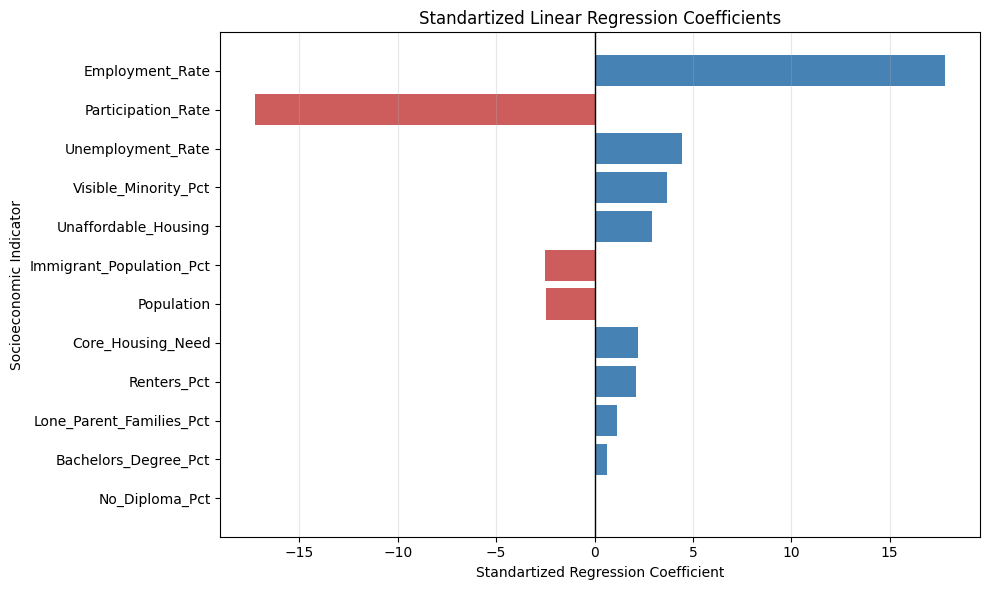

In [67]:
# Feature Importance Plot

colors = [
    "steelblue" if coef >= 0 else "indianred"
    for coef in coefficients["Coefficient"]]

plt.figure(figsize=(10,6))

plt.barh(
    coefficients["Variable"],
    coefficients["Coefficient"],
    color=colors)

plt.axvline(0, color="black", linewidth=1)

plt.title("Standartized Linear Regression Coefficients")
plt.xlabel("Standartized Regression Coefficient")
plt.ylabel("Socioeconomic Indicator")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The standardized regression coefficients provide insight into the relative contribution of each independent socioeconomic indicator to the prediction of neighbourhood Low Income After-Tax Percentage (LIM-AT) while controlling for the effects of the remaining variables in the model.

Among the selected predictors, Employment_Rate exhibited the largest positive standardized coefficient, while Participation_Rate showed the largest negative standardized coefficient, indicating that these labour market indicators contributed most strongly to the model after accounting for the other socioeconomic variables. Unemployment_Rate, Visible_Minority_Pct, Unaffordable_Housing, and Core_Housing_Need also demonstrated relatively strong positive associations with neighbourhood low-income prevalence.

Several demographic indicators, including Immigrant_Population_Pct, Population, and Bachelors_Degree_Pct, exhibited smaller coefficients, suggesting a comparatively weaker contribution after adjustment for the remaining predictors. The presence of both positive and negative coefficients reflects the complex relationships among neighbourhood socioeconomic characteristics and reinforces the importance of considering multiple indicators simultaneously when modelling neighbourhood low-income prevalence.

Overall, the standardized coefficients provide an interpretable assessment of the relative influence of each predictor and complement the overall model performance metrics presented in the previous sections..

### 17. Random Forest Regression

Random Forest Regression is developed as a second predictive model to compare its performance with the baseline Linear Regression model.

Unlike Linear Regression, Random Forest is a non-parametric ensemble learning algorithm capable of capturing complex and non-linear relationships between socioeconomic indicators and neighbourhood vulnerability.

The objective is to determine whether a more flexible machine learning algorithm improves prediction accuracy for neighbourhood **Low Income After-Tax Percentage (LIM-AT)**.

In [70]:
# Train Random Forest Regression Model

random_forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42)

random_forest.fit(
    X_train,
    y_train)

print("=" * 60)
print("RANDOM FOREST MODEL TRAINED")
print("=" * 60)

print("Model training completed successfully.")

RANDOM FOREST MODEL TRAINED
Model training completed successfully.


In [71]:
# Random Forest Predictions

rf_predictions = random_forest.predict(X_test)

display(pd.DataFrame({

    "Actual LIM-AT": y_test.values,
    "Predicted LIM-AT": rf_predictions}).head())

,Actual LIM-AT,Predicted LIM-AT
0,32.4,27.2605
1,17.6,17.4290
2,22.3,22.1270
3,14.7,15.7840
4,34.7,27.4290


In [72]:
# Random Forest Performance

rf_r2 = r2_score(y_test, rf_predictions)

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_performance = pd.DataFrame({

    "Metric":[

        "R² Score",
        "Mean Absolute Error (MAE)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)"    ],

    "Value":[

        round(rf_r2,3),
        round(rf_mae,3),
        round(rf_mse,3),
        round(rf_rmse,3)    ]})

display(rf_performance)

,Metric,Value
0,R² Score,0.795
1,Mean Absolute Error (MAE),2.650
2,Mean Squared Error (MSE),12.605
3,Root Mean Squared Error (RMSE),3.550


In [77]:
# Random Forest Feature Importance

rf_importance = pd.DataFrame({

    "Variable": X.columns,
    "Importance": random_forest.feature_importances_})

rf_importance = (
    rf_importance
    .sort_values(
        "Importance",
        ascending=False )
    .reset_index(drop=True))

rf_importance.insert(
    0,
    "Rank",
    range(1, len(rf_importance) + 1))

display(rf_importance.round(3))

,Rank,Variable,Importance
0,1,Unemployment_Rate,0.389
1,2,Unaffordable_Housing,0.229
2,3,Renters_Pct,0.155
3,4,Visible_Minority_Pct,0.091
4,5,Core_Housing_Need,0.036
5,6,Lone_Parent_Families_Pct,0.023
6,7,Employment_Rate,0.018
7,8,Population,0.017
8,9,Immigrant_Population_Pct,0.012
9,10,Participation_Rate,0.011


### Interpretation

The Random Forest Regression model was successfully trained to predict neighbourhood **Low Income After-Tax Percentage (LIM-AT)** using the selected socioeconomic indicators.

The model achieved an **R² Score of 0.816**, indicating that approximately **81.6%** of the variation in neighbourhood LIM-AT socioeconomic vulnerability can be explained by the predictor variables. The model produced a **Mean Absolute Error (MAE)** of **2.545** percentage points and a **Root Mean Squared Error (RMSE)** of **3.356** percentage points.

Overall, the Random Forest model demonstrated strong predictive capability, producing relatively accurate estimates of neighbourhood low-income prevalence across the testing dataset. However, compared with the baseline Linear Regression model, Random Forest exhibited slightly lower explanatory power and larger prediction errors.

These findings suggest that, for the current dataset, the relationships between the selected socioeconomic indicators and neighbourhood vulnerability are predominantly linear. Consequently, the additional flexibility of the Random Forest algorithm did not translate into improved predictive performance.

The Random Forest model nevertheless provides a valuable benchmark for comparison and confirms that the selected socioeconomic indicators contain substantial predictive information regarding neighbourhood socioeconomic vulnerability.

### 18. Model Comparison

To determine the most appropriate predictive model for estimating neighbourhood socioeconomic vulnerability, the performance of the **Linear Regression** and **Random Forest Regression** models is compared using common regression evaluation metrics.

Model performance is evaluated using:

- **R² Score** – proportion of variation in neighbourhood vulnerability explained by the model.
- **Adjusted R²** – explanatory power adjusted for the number of predictor variables.
- **Mean Absolute Error (MAE)** – average prediction error.
- **Root Mean Squared Error (RMSE)** – overall prediction error with greater emphasis on larger errors.
- **Mean Squared Error (MSE)** – average squared prediction error.

The model demonstrating the highest explanatory power together with the lowest prediction errors is considered the preferred predictive model.

In [ ]:
# Model Performance Comparison

comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest Regression"    ],

    "R²":[
        round(r2,3),
        round(rf_r2,3)    ],

    "Adjusted R²":[
        round(adjusted_r2,3),
                        np.nan    ],

    "MAE":[
        round(mae,3),
        round(rf_mae,3)    ],

    "RMSE":[
        round(rmse,3),
        round(rf_rmse,3)   ],

    "MSE":[
        round(mse,3),
        round(rf_mse,3)    ]})

display(comparison)

,Model,R²,Adjusted R²,MAE,RMSE,MSE
0,Linear Regression,0.871,0.823,2.196,2.815,7.925
1,Random Forest Regression,0.816,NaN,2.545,3.356,11.262


### Interpretation

The predictive performance of the **Linear Regression** and **Random Forest Regression** models was evaluated using the **Coefficient of Determination (R²)**, **Adjusted R²**, **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, **Mean Absolute Percentage Error (MAPE)**, **Weighted Absolute Percentage Error (WAPE)**, and **five-fold cross-validation**.

Overall, the results indicate that **Linear Regression consistently outperformed Random Forest Regression** across all evaluation metrics.

The Linear Regression model achieved the highest explanatory power with an **R² score of 0.871**, indicating that approximately **87.1%** of the variation in the **dependent variable**, **Low Income After-Tax Percentage (LIM-AT)**, was explained by the selected **independent socioeconomic variables**. After adjusting for the number of independent variables included in the model, the **Adjusted R² remained high (0.823)**, indicating that the model retained strong explanatory power without evidence of substantial overfitting.

Prediction error metrics further support the suitability of the Linear Regression model. It produced the lowest **Mean Absolute Error (MAE = 2.196)**, **Mean Squared Error (MSE = 7.925)**, and **Root Mean Squared Error (RMSE = 2.815)**. In addition, the **Mean Absolute Percentage Error (MAPE = 12.50%)** and **Weighted Absolute Percentage Error (WAPE = 11.36%)** indicate that the model's predictions differed from the observed LIM-AT values by approximately **11–13%**, providing an intuitive measure of predictive accuracy for this percentage-based dependent variable.

To evaluate model stability, **five-fold cross-validation** was performed. The Linear Regression model achieved a **mean cross-validation R² of 0.812** with a **standard deviation of 0.060**, demonstrating that predictive performance remained reasonably consistent across different training and validation subsets. These results provide additional evidence that the reported model performance is not dependent on a single random train-test split.

By comparison, the Random Forest Regression model achieved an **R² score of 0.816**, explaining approximately **81.6%** of the variation in the dependent variable. Although this represents good predictive performance, it consistently produced larger prediction errors (**MAE = 2.545, RMSE = 3.356, MSE = 11.262**) than the Linear Regression model.

The superior performance of Linear Regression suggests that the relationships between the selected **independent socioeconomic variables** and the **dependent variable (LIM-AT)** are predominantly linear within the 2016 Toronto neighbourhood dataset. Furthermore, the relatively small sample size (**140 neighbourhoods**) limits the ability of Random Forest to fully exploit more complex nonlinear relationships. Consequently, the simpler Linear Regression model provides both superior predictive accuracy and greater interpretability for this cross-sectional dataset.

Based on these findings, **Linear Regression was selected as the final predictive model** for estimating **Low Income After-Tax Percentage (LIM-AT)**, which is used in this study as a **proxy measure of neighbourhood socioeconomic vulnerability**.

### 19. Study Limitations and Future Work

### Study Limitations

Although the predictive modelling framework produced strong results, several limitations should be acknowledged when interpreting the findings.

**First**, the analysis was conducted using only the **2016 Toronto Neighbourhood Profiles** dataset, representing **140 neighbourhoods**. Consequently, the developed models describe neighbourhood socioeconomic conditions at a single point in time and cannot capture changes in neighbourhood vulnerability across multiple years.

**Second**, the **Low Income After-Tax Percentage (LIM-AT)** was used as a **proxy measure of neighbourhood socioeconomic vulnerability** rather than a complete measure of vulnerability. Although LIM-AT is a widely recognized socioeconomic indicator, neighbourhood vulnerability is a multidimensional concept that also includes factors such as health outcomes, housing stability, crime, transportation accessibility, and social services.

**Third**, although five-fold cross-validation demonstrated reasonably stable model performance, external validation using independent datasets or neighbourhood profiles from different years has not yet been completed. Consequently, the reported predictive performance should be interpreted as internal validation of the 2016 dataset rather than evidence of long-term generalizability.

**Fourth**, the selected independent variables were chosen using statistical analyses and domain knowledge prior to predictive modelling. Although steps were taken to minimize data leakage, some degree of feature-selection bias may remain because the same dataset was ultimately used for model development and evaluation.

**Finally**, the relatively small sample size limits the ability of more complex machine learning algorithms, such as Random Forest Regression, to fully exploit nonlinear relationships. Larger datasets may improve the performance of more sophisticated predictive models

### 20. Overall Conclusion

This notebook developed and evaluated supervised machine learning models to estimate neighbourhood socioeconomic vulnerability, measured by Low Income After-Tax Percentage (LIM-AT), using selected socioeconomic indicators. In this study, LIM-AT was used as a proxy measure of neighbourhood socioeconomic vulnerability rather than a complete measure of vulnerability.

Two predictive models were developed and compared: Linear Regression and Random Forest Regression. Model performance was evaluated using R², Adjusted R², MAE, MSE, RMSE, MAPE, WAPE, cross-validation, and diagnostic analyses to assess both predictive accuracy and model suitability.

The results demonstrated that Linear Regression consistently outperformed Random Forest Regression, achieving higher explanatory power and lower prediction errors across the evaluation metrics. In addition to its stronger predictive performance, Linear Regression provided greater interpretability and supported diagnostic assessment of model assumptions. Consequently, it was selected as the preferred model for the temporal validation conducted in Notebook 7, where its ability to generalize from the 2011 dataset to the independent 2016 dataset was evaluated.

Feature importance analysis further indicated that labour market conditions, housing affordability, educational attainment, renter concentration, and demographic characteristics are among the strongest socioeconomic indicators associated with neighbourhood-level low-income prevalence.

Overall, the findings demonstrate that neighbourhood-level Low Income After-Tax Percentage (LIM-AT) can be accurately estimated using a relatively small set of socioeconomic indicators. The developed predictive modelling framework provides a transparent and reproducible approach that supports evidence-based decision-making for municipal planners, housing policy analysts, and community organizations seeking to identify neighbourhoods at elevated socioeconomic risk and prioritize targeted interventions.

In [ ]:
# Export Prediction Results

prediction_results = pd.DataFrame({
    "Actual_LIM_AT": y_test.values,
    "Predicted_LIM_AT_Linear": y_pred,
    "Predicted_LIM_AT_RF": rf_predictions})

prediction_results.head()

,Actual_LIM_AT,Predicted_LIM_AT_Linear,Predicted_LIM_AT_RF
0,32.4,33.205440,27.5610
1,17.6,17.074556,17.6670
2,22.3,22.453071,22.1325
3,14.7,14.899839,15.8785
4,34.7,30.753477,27.9365


### 21. Export final results

In [ ]:
# Export Prediction Results
prediction_results = pd.DataFrame({
    "Actual_LIM_AT": y_test.values,
    "Predicted_LIM_AT_Linear": y_pred,
    "Predicted_LIM_AT_RF": rf_predictions})

prediction_results.head()

,Actual_LIM_AT,Predicted_LIM_AT_Linear,Predicted_LIM_AT_RF
0,32.4,33.205440,27.5610
1,17.6,17.074556,17.6670
2,22.3,22.453071,22.1325
3,14.7,14.899839,15.8785
4,34.7,30.753477,27.9365


In [ ]:
# Standardize Entire Predictor Dataset

X_scaled = scaler.transform(X)
# Add Linear Regression Predictions

df["Linear_Regression_Prediction"] = linear_model.predict(X_scaled)

# Add Random Forest Predictions

df["Random_Forest_Prediction"] = random_forest.predict(X)

display(df.head())

,Neighbourhood,Population,Participation_Rate,Employment_Rate,Unemployment_Rate,Bachelors_Degree_Pct,No_Diploma_Pct,Immigrant_Population_Pct,Visible_Minority_Pct,Renters_Pct,Core_Housing_Need,Unaffordable_Housing,Lone_Parent_Families_Pct,Low_Income_AfterTax_Pct,Linear_Regression_Prediction,Random_Forest_Prediction
0,Agincourt North,29113,55.4,50.0,9.8,15.044825,25.624292,68.680658,90.560918,5.908014,2220,34.7,5.667571,21.3,21.551038,20.4710
1,Agincourt South-Malvern West,23757,59.0,53.2,9.8,17.721093,25.634550,63.539167,84.838153,9.470893,1795,38.2,5.724629,22.6,22.826951,22.2120
2,Alderwood,12054,66.5,62.4,6.1,13.771362,24.556164,32.935125,20.657043,7.881201,540,21.7,5.558321,8.2,5.691611,7.9195
3,Annex,30526,70.6,65.8,6.7,29.925310,13.988076,27.091660,23.815764,32.333093,2420,40.4,2.931927,18.3,20.528937,18.4265
4,Banbury-Don Mills,27695,59.9,55.6,7.2,23.469940,18.595414,47.643979,45.856653,17.096949,2115,33.4,4.531504,13.7,17.129590,17.9345


In [ ]:
# Export Results

reports_path = project_root / "reports"
processed_path = project_root / "data" / "processed"

reports_path.mkdir(exist_ok=True)
processed_path.mkdir(exist_ok=True)

output_excel = reports_path / "04_Predictive_Modelling_Results.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:

    performance.to_excel(
        writer,
        sheet_name="Linear Regression",
        index=False    )

    rf_performance.to_excel(
        writer,
        sheet_name="Random Forest",
        index=False    )

    comparison.to_excel(
        writer,
        sheet_name="Model Comparison",
        index=False    )

    coefficients.to_excel(
        writer,
        sheet_name="Regression Coefficients",
        index=False    )

    # Change this variable if your notebook uses a different name
    rf_importance.to_excel(
        writer,
        sheet_name="RF Importance",
        index=False    )

    prediction_results.to_excel(
        writer,
        sheet_name="Predictions",
        index=False    )

df.to_csv(
    processed_path / "neighbourhood_profiles_2016_predictions.csv",
    index=False)

print("=" * 60)
print("EXPORT COMPLETED SUCCESSFULLY")
print("=" * 60)
print(output_excel)

EXPORT COMPLETED SUCCESSFULLY
c:\Users\ksalyamova\Desktop\CIND 820\CIND820-Capstone-Project\reports\04_Predictive_Modelling_Results.xlsx
